# Lab 05: Redes Neuronales en PyTorch
**Cuadernillo 3: Clasificación Multiclase Multimodal (Imágenes FER-2013)**

##Estudiante:
* Delgado Ramos Jorge Luis

## 1. Importación y Preprocesamiento de Datos Complejos
Este cuadernillo aborda el desafío de la visión artificial básica procesando el dataset FER-2013 (Reconocimiento de Expresiones Faciales). El objetivo es clasificar imágenes de rostros en 7 emociones distintas.

Dado el formato comprimido del dataset original (donde los 2304 píxeles de cada imagen vienen como cadenas de texto separadas por espacios), la clase personalizada `Dataset` de PyTorch juega un papel crucial. En su método constructor:
1. Iteramos la columna de texto para transformarla en arreglos numéricos (`np.float32`).
2. Reconstruimos la "Matriz de Diseño" ($X$) y aplicamos una normalización Z-score estricta para estandarizar la iluminación.
3. Transformamos la variable objetivo ($y$) en un tensor de tipo `Long`, requisito fundamental para la función de pérdida `CrossEntropyLoss` de PyTorch.

Por último, el `DataLoader` automatiza la creación de lotes iterables (batches) de 64 imágenes para optimizar el uso de la memoria RAM y acelerar la retropropagación en la GPU.

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 1. Clase Dataset Avanzada para extracción de características
class FacialExpressionDataset(Dataset):
    def __init__(self, archivo_csv):
        print("Cargando y decodificando el dataset FER-2013...")
        print("Esto tomará unos segundos debido a la extracción de píxeles...")

        datos = pd.read_csv(archivo_csv)

        # Extracción de la etiqueta 'emotion' (Variable Y). Tipo LONG es obligatorio para CrossEntropyLoss
        self.y = torch.tensor(datos['emotion'].values, dtype=torch.long)

        # Extracción de píxeles (Variable X)
        X_lista = []
        for secuencia in datos['pixels']:
            pixeles = np.array(secuencia.split(' '), dtype=np.float32)
            X_lista.append(pixeles)

        X_numpy = np.array(X_lista)

        # Normalización Z-Score de la iluminación
        mu = np.mean(X_numpy, axis=0)
        sigma = np.std(X_numpy, axis=0)
        sigma[sigma == 0] = 1 # Evitar división por cero en píxeles negros
        X_norm = (X_numpy - mu) / sigma

        # Conversión final a Tensor de PyTorch
        self.X = torch.tensor(X_norm, dtype=torch.float32)

        self.n_muestras = self.X.shape[0]
        self.n_caracteristicas = self.X.shape[1]

    def __len__(self):
        return self.n_muestras

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Instanciamos el dataset
dataset_fer = FacialExpressionDataset('/content/drive/MyDrive/Colab Notebooks/SIS-420/Laboratorio 05/Lab_05_RN_Pytorch_Cuad_03/FER-2013.csv')

# DataLoader con un batch size mayor por la cantidad de datos
dataloader_fer = DataLoader(dataset=dataset_fer, batch_size=64, shuffle=True)

print(f"\nDataset Multimodal listo.")
print(f"Total de imágenes procesadas: {dataset_fer.n_muestras}")
print(f"Píxeles por imagen (n): {dataset_fer.n_caracteristicas}")

Cargando y decodificando el dataset FER-2013...
Esto tomará unos segundos debido a la extracción de píxeles...

Dataset Multimodal listo.
Total de imágenes procesadas: 28709
Píxeles por imagen (n): 2304


## 2. Arquitectura de la Red Neuronal Profunda (Deep MLP)
Para lograr que el modelo comprenda geometrías no lineales (como la curvatura de una sonrisa o el contorno de un ojo), abandonamos el enfoque puramente lineal de la Regresión Logística y construimos una Red Neuronal Profunda heredando de `torch.nn.Module`.

**Estructura del Modelo:**
* **Capa Oculta 1:** Recibe los 2304 píxeles y extrae patrones hacia 512 neuronas.
* **Capa Oculta 2:** Comprime y refina la información de 512 a 128 neuronas.
* **Activaciones:** Se utiliza `ReLU` después de cada capa oculta para "doblar" el hiperplano y permitir la separación no lineal.
* **Capa de Salida:** Mapea las 128 neuronas finales a 7 salidas (una por cada emoción).
* **Optimizador y Costo:** Empleamos la función `CrossEntropyLoss`, la cual ya integra matemáticamente la función Softmax para calcular la probabilidad de las 7 clases simultáneamente de forma eficiente.

In [4]:
# DEFINICIÓN DE LA RED NEURONAL MULTICAPA

# Heredamos de nn.Module
class RedFacialFER(nn.Module):
    def __init__(self, input_size, num_classes):
        super(RedFacialFER, self).__init__()
        # Arquitectura profunda
        self.capa1 = nn.Linear(input_size, 512)
        self.relu1 = nn.ReLU()
        self.capa2 = nn.Linear(512, 128)
        self.relu2 = nn.ReLU()

        # Salida de 7 clases (emociones)
        self.capa_salida = nn.Linear(128, num_classes)

    def forward(self, x):
        out = self.capa1(x)
        out = self.relu1(out)
        out = self.capa2(out)
        out = self.relu2(out)
        out = self.capa_salida(out)
        # Retornamos los logits crudos para CrossEntropyLoss
        return out

# Dispositivo de entrenamiento
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de entrenamiento: {device}")
if device.type == 'cuda':
    print(f"Aceleración gráfica activada: {torch.cuda.get_device_name(0)}")

# Instanciamos el modelo con 7 clases de salida
modelo_fer = RedFacialFER(input_size=dataset_fer.n_caracteristicas, num_classes=7).to(device)

# Función de pérdida para Multiclase (Softmax interno)
criterio_fer = nn.CrossEntropyLoss()
# Optimizador Adam
optimizador_fer = torch.optim.Adam(modelo_fer.parameters(), lr=0.001)

print("\nArquitectura del Modelo:")
print(modelo_fer)

Dispositivo de entrenamiento: cpu

Arquitectura del Modelo:
RedFacialFER(
  (capa1): Linear(in_features=2304, out_features=512, bias=True)
  (relu1): ReLU()
  (capa2): Linear(in_features=512, out_features=128, bias=True)
  (relu2): ReLU()
  (capa_salida): Linear(in_features=128, out_features=7, bias=True)
)


## 3. Bucle de Entrenamiento (Multiclase) y Evaluación de Precisión
El entrenamiento de esta red profunda requiere que el modelo procese los lotes de imágenes y ajuste sus miles de pesos internos.

**Proceso matemático de la iteración:**
1. **Forward Pass:** Se envían los 2304 píxeles a través de las capas ocultas y las activaciones ReLU hasta obtener 7 "logits" (uno por emoción).
2. **Cálculo de Pérdida:** La función `CrossEntropyLoss` toma estos 7 logits, les aplica internamente la función Softmax para convertirlos en probabilidades y calcula el error logarítmico frente a la etiqueta real.
3. **Retropropagación:** Mediante `loss.backward()` calculamos los gradientes y con `optimizador.step()` ajustamos los pesos.
4. **Cálculo de Precisión:** Para saber qué emoción eligió la red, utilizamos `torch.argmax` sobre la dimensión de las 7 salidas. Esto nos devuelve el índice de la neurona con el valor más alto (la emoción ganadora), la cual comparamos con la etiqueta real para calcular el porcentaje de exactitud de la época.

Iniciando entrenamiento de la red profunda FER-2013...
Este proceso tomará tiempo debido a la cantidad de datos y parámetros.
Época [5/100] | Pérdida: 1.3785 | Precisión: 46.65%
Época [10/100] | Pérdida: 1.1130 | Precisión: 57.18%
Época [15/100] | Pérdida: 0.8649 | Precisión: 66.60%
Época [20/100] | Pérdida: 0.6869 | Precisión: 73.93%
Época [25/100] | Pérdida: 0.5492 | Precisión: 79.29%
Época [30/100] | Pérdida: 0.4757 | Precisión: 82.14%
Época [35/100] | Pérdida: 0.3948 | Precisión: 85.05%
Época [40/100] | Pérdida: 0.3550 | Precisión: 86.62%
Época [45/100] | Pérdida: 0.3011 | Precisión: 88.67%
Época [50/100] | Pérdida: 0.3103 | Precisión: 88.66%
Época [55/100] | Pérdida: 0.2634 | Precisión: 90.34%
Época [60/100] | Pérdida: 0.2498 | Precisión: 90.91%
Época [65/100] | Pérdida: 0.2251 | Precisión: 91.99%
Época [70/100] | Pérdida: 0.2347 | Precisión: 91.72%
Época [75/100] | Pérdida: 0.2076 | Precisión: 92.90%
Época [80/100] | Pérdida: 0.1951 | Precisión: 92.92%
Época [85/100] | Pérdida: 0

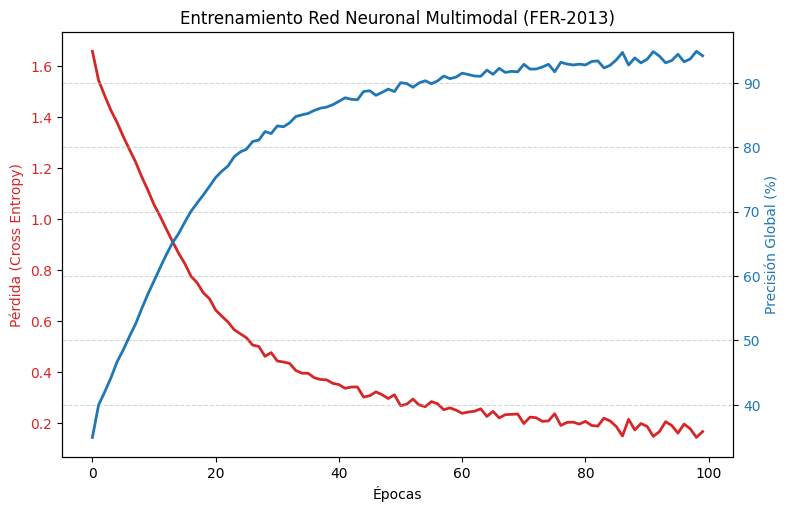

In [5]:
# ENTRENAMIENTO Y CÁLCULO DE PRECISIÓN MULTICLASE

num_epochs = 100
historial_perdida = []
historial_precision = []

print("Iniciando entrenamiento de la red profunda FER-2013...")
print("Este proceso tomará tiempo debido a la cantidad de datos y parámetros.")

for epoch in range(num_epochs):
    perdida_acumulada = 0.0
    correctos = 0
    total = 0

    # Procesamiento por lotes
    for entradas, etiquetas in dataloader_fer:
        entradas = entradas.to(device)
        etiquetas = etiquetas.to(device)

        # 1. Forward pass
        logits = modelo_fer(entradas)
        perdida = criterio_fer(logits, etiquetas)

        # 2. Backward pass y optimización
        optimizador_fer.zero_grad()
        perdida.backward()
        optimizador_fer.step()

        perdida_acumulada += perdida.item()

        # 3. Precisión del lote (Buscamos el índice del valor más alto)
        _, predicciones = torch.max(logits, 1)
        correctos += (predicciones == etiquetas).sum().item()
        total += etiquetas.size(0)

    # Métricas finales de la época
    perdida_promedio = perdida_acumulada / len(dataloader_fer)
    precision_epoca = (correctos / total) * 100

    historial_perdida.append(perdida_promedio)
    historial_precision.append(precision_epoca)

    if (epoch+1) % 5 == 0:
        print(f'Época [{epoch+1}/{num_epochs}] | Pérdida: {perdida_promedio:.4f} | Precisión: {precision_epoca:.2f}%')

# Gráficas de rendimiento
fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:red'
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Pérdida (Cross Entropy)', color=color)
ax1.plot(historial_perdida, color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Precisión Global (%)', color=color)
ax2.plot(historial_precision, color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Entrenamiento Red Neuronal Multimodal (FER-2013)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 4. Persistencia del Modelo (Checkpoints) y Reconstrucción Visual
Para finalizar, el conocimiento adquirido por las matrices de pesos de la red profunda se extrae y guarda en un archivo `.pth`.

Simulando un pase a producción, inicializamos una red vacía y le cargamos el `state_dict` guardado. Para demostrar la efectividad de la visión artificial, tomaremos una fila aleatoria de nuestro dataset, pasaremos el vector numérico por la red recuperada y realizaremos una transformación inversa (Reshape de 48x48) para graficar el rostro evaluado en pantalla junto con la predicción generada por el modelo recuperado.

Red Profunda guardada en: modelo_fer2013_lab05.pth
Levantando modelo desde el Checkpoint...

--- PREDICCIÓN DEL CHECKPOINT ---
Emoción Real: Miedo
Emoción Predicha por la IA: Miedo


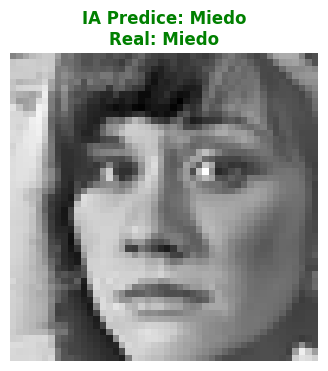

In [8]:
# CHECKPOINTS Y PRUEBA DE VISIÓN ARTIFICIAL

# Etiquetas oficiales de emociones del FER-2013
emociones = ['Enojo', 'Asco', 'Miedo', 'Felicidad', 'Tristeza', 'Sorpresa', 'Neutral']

# 1. GUARDADO DE PESOS
ruta_modelo_fer = 'modelo_fer2013_lab05.pth'
torch.save(modelo_fer.state_dict(), ruta_modelo_fer)
print(f"Red Profunda guardada en: {ruta_modelo_fer}")

# 2. CARGA DEL MODELO EN PRODUCCIÓN
print("Levantando modelo desde el Checkpoint...")
modelo_fer_recuperado = RedFacialFER(input_size=dataset_fer.n_caracteristicas, num_classes=7).to(device)
modelo_fer_recuperado.load_state_dict(torch.load(ruta_modelo_fer))
modelo_fer_recuperado.eval() # Fundamental para inferencia

# 3. PREDICCIÓN Y VISUALIZACIÓN
with torch.no_grad():
    # Elegimos una imagen aleatoria
    idx_prueba = np.random.randint(0, dataset_fer.n_muestras)
    muestra_x = dataset_fer.X[idx_prueba].unsqueeze(0).to(device)
    etiqueta_real = dataset_fer.y[idx_prueba].item()

    # La red predice
    logits_prediccion = modelo_fer_recuperado(muestra_x)
    _, indice_predicho = torch.max(logits_prediccion, 1)
    emocion_predicha = indice_predicho.item()

    # Mostramos los resultados en consola
    print("\n--- PREDICCIÓN DEL CHECKPOINT ---")
    print(f"Emoción Real: {emociones[etiqueta_real]}")
    print(f"Emoción Predicha por la IA: {emociones[emocion_predicha]}")

    # Reconstruimos la imagen para verla en pantalla
    imagen_reconstruida = dataset_fer.X[idx_prueba].numpy().reshape(48, 48)

    plt.figure(figsize=(4, 4))
    plt.imshow(imagen_reconstruida, cmap='gray')
    plt.axis('off')

    color_titulo = 'green' if etiqueta_real == emocion_predicha else 'red'
    plt.title(f"IA Predice: {emociones[emocion_predicha]}\nReal: {emociones[etiqueta_real]}", color=color_titulo, fontweight='bold')
    plt.show()